In [54]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

import csv
import h5py
import json
from datetime import datetime
import sys
import os
import shutil
import importlib
from itertools import product

sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_simulations")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\paper_data_and_simulations\ramp_dephasing_simulations")

import current_measurements.src.src_current_measurement_simulations_particle_sector
importlib.reload(current_measurements.src.src_current_measurement_simulations_particle_sector);
from current_measurements.src.src_current_measurement_simulations_particle_sector import CurrentMeasurementSimulationParticleSector

import current_simulations.quantum_states
importlib.reload(current_simulations.quantum_states)
from current_simulations.quantum_states import QuantumState, FockBasisState, FockBasisOuter, DensityMatrix

import quantum_states
importlib.reload(quantum_states)
from quantum_states import QuantumState, FockBasisState, FockBasisOuter, DensityMatrix

import current_simulations.current_simulation
importlib.reload(current_simulations.current_simulation)
from current_simulations.current_simulation import CurrentSimulation


import qt_qubit_sys
importlib.reload(qt_qubit_sys)
from qt_qubit_sys import *

# 1. No Dephasing

### 1.1 Helpers

In [41]:
def convert_particle_sector_to_reduced_density_matrix(psi_4particle, 
                                                      basis_4particle, 
                                                      reduced_qubit_indices, 
                                                      num_qubits=8,
                                                      num_levels=5):
    """
    More efficient version that groups states by their traced configurations
    Handles both state vectors and density matrices as input.

    after reducing to reduced density matrix, truncate to remove states that have more than 4 particles in total
    """
    from collections import defaultdict
    
    # Check if input is a density matrix or state vector
    if hasattr(psi_4particle, 'shape') and len(psi_4particle.shape) == 2:
        # Input is a density matrix
        is_density_matrix = True
        if hasattr(psi_4particle, 'full'):
            rho_input = psi_4particle.full()  # QuTiP Qobj
        else:
            rho_input = psi_4particle  # numpy array
    else:
        # Input is a state vector
        is_density_matrix = False
        if hasattr(psi_4particle, 'full'):
            psi_input = psi_4particle.full().flatten()  # QuTiP Qobj
        else:
            psi_input = psi_4particle.flatten()  # numpy array
    

    if psi_4particle.isket:
        is_density_matrix = False
        psi_input = psi_4particle.full().flatten()

    elif psi_4particle.isoper:
        is_density_matrix = True
        rho_input = psi_4particle.full()



    traced_qubits = [i for i in range(num_qubits) if i not in reduced_qubit_indices]
    
    # Group states by (reduced_config, traced_config)
    state_groups = defaultdict(list)
    
    for i, full_state in enumerate(basis_4particle):
        reduced_part = tuple(full_state[j] for j in reduced_qubit_indices)
        traced_part = tuple(full_state[j] for j in traced_qubits)
        state_groups[(reduced_part, traced_part)].append(i)
    
    # Generate basis for reduced qubits
    reduced_basis = list(product(range(num_levels), repeat=len(reduced_qubit_indices)))
    dim_reduced = len(reduced_basis)
    rho_reduced = np.zeros((dim_reduced, dim_reduced), dtype=complex)
    
    # Build density matrix
    for alpha, reduced_alpha in enumerate(reduced_basis):
        for beta, reduced_beta in enumerate(reduced_basis):
            
            matrix_element = 0.0
            
            # Sum over all traced configurations
            all_traced_configs = set()
            for (red_part, traced_part), indices in state_groups.items():
                if red_part == reduced_alpha or red_part == reduced_beta:
                    all_traced_configs.add(traced_part)
            
            for traced_config in all_traced_configs:
                indices_alpha = state_groups.get((reduced_alpha, traced_config), [])
                indices_beta = state_groups.get((reduced_beta, traced_config), [])
                
                if is_density_matrix:
                    # For density matrix input: Tr_traced[rho] = sum over traced indices
                    for i in indices_alpha:
                        for j in indices_beta:
                            matrix_element += rho_input[i, j]
                else:
                    # For state vector input: |psi><psi| -> sum coefficients
                    coeff_alpha = sum(psi_input[i] for i in indices_alpha)
                    coeff_beta = sum(psi_input[i] for i in indices_beta)
                    matrix_element += coeff_alpha * np.conj(coeff_beta)

            rho_reduced[alpha, beta] = matrix_element

    
    basis_4Q_reduced_indices = np.where([sum(state) <= 4 for state in reduced_basis])[0]
    rho_reduced = rho_reduced[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    
    return qt.Qobj(rho_reduced, dims=[[len(basis_4Q_reduced_indices)], [len(basis_4Q_reduced_indices)]])

In [42]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)


def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)


def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

### 1.2 Sweep $J/J_{||}$

In [43]:
### initialize parameters

J = 5.77 * 2 * np.pi # 2pi MHz
U = -180 * 2 * np.pi # 2pi MHz

# testing different Us
# U = 0

T1 = None
T2 = None

psi0 = -1
times = np.linspace(0, 0.15, 11)


ratios = np.linspace(-3, 3, 101)
ratios = np.linspace(-3.5, 3.5, 101)
# ratios = np.array([1])

J_parallel_sweep = J * ratios

In [44]:
num_levels = 5
num_qubits = 8
num_particles = 4

basis = list(product(range(num_levels), repeat=num_qubits))
basis_4Q = [state for state in basis if sum(state) == num_particles]




correlation_pairs = []
for i in range(1, 8):
    for j in range(i + 2, 8):
        correlation_pairs.append(((i, i+1), (j,j+1)))



In [18]:
chiral_order_parameters = []

for i in range(len(J_parallel_sweep)):

    J_parallel = J_parallel_sweep[i]

    # create initial state from diagonalizing the particle sector Hamiltonian

    simulation = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J_parallel, U, times,
                                                        [1,2], [3,4], psi0=psi0, T1=T1, T2=T2)

    psi0_state = simulation.psi0


    current_simulation = CurrentSimulation(num_levels, num_qubits, num_particles, J_parallel, J, 0, U)
    psi0_state = simulation.psi0


    # create fock state out of psi0

    basis_4Q_fock = [FockBasisState(state) for state in basis_4Q]

    # basis_fock = [FockBasisState(state) for state in basis]

    assert psi0_state.isket
    psi0_fock = QuantumState(psi0_state.full()[:,0], basis_4Q_fock)

    current_simulation.psi0 = psi0_fock
    current_correlations_from_operator = current_simulation.get_current_correlations(only_rungs=True)

    # remove pairs that share a vertex, and redefine signs (1,2),(4,5) is positive in pi flux

    current_correlations_from_operator_normalized = {}

    for correlation_pair in correlation_pairs:
        pair_1, pair_2 = correlation_pair

        multiplier = 1
        if abs(min(pair_1) - min(pair_2)) % 2 == 1:
            multiplier = -1

        current_correlations_from_operator_normalized[correlation_pair] = current_correlations_from_operator[correlation_pair]
        current_correlations_from_operator_normalized[correlation_pair] *= multiplier


    current_correlation_by_distance_operator = {}


    for correlation_pair in correlation_pairs:

        current_correlation_value = current_correlations_from_operator_normalized[correlation_pair]

        distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))

        if not distance in current_correlation_by_distance_operator:
            current_correlation_by_distance_operator[distance] = []
        
        current_correlation_by_distance_operator[distance].append(current_correlation_value)


    distances = []
    current_correlation_averages_operator = []

    for distance in current_correlation_by_distance_operator:
        distances.append(distance)
        current_correlation_averages_operator.append(np.mean(current_correlation_by_distance_operator[distance]))


    current_correlation_total_operator = sum(current_correlation_averages_operator)
    print(f'current correlation total operator: {current_correlation_total_operator}')

    # we need to create the full data dictionary because it doesn't update nested items


    data_dictionary = {}

    for correlation_pair in correlation_pairs:

        data_dictionary[correlation_pair] = {}


        data_dictionary[correlation_pair]['current_correlation_value'] = current_correlations_from_operator_normalized[correlation_pair]

    data_dictionary['distances'] = distances

    data_dictionary['current_correlation_averages'] = current_correlation_averages_operator
    data_dictionary['distance_to_current_correlation_value'] = current_correlation_by_distance_operator
    data_dictionary['current_correlation_total'] = current_correlation_total_operator


    chiral_order_parameters.append(current_correlation_total_operator)




processing psi0, given type: <class 'int'>
current correlation total operator: 39.09860894373441
processing psi0, given type: <class 'int'>
current correlation total operator: 38.78071131342107
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\mattm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\mattm\AppData\Local\Temp\ipykernel_1940\1190080641.py", line 9, in <module>
    simulation = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J_parallel, U, times,
  File "C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements\src\src_current_measurement_simulations_particle_sector.py", line 10, in __init__
    super().__init__(num_levels, num_qubits, num_particles, J, J_parallel, U, times, readout_pair_1, readout_pair_2, initial_detunings,
  File "C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measuremen

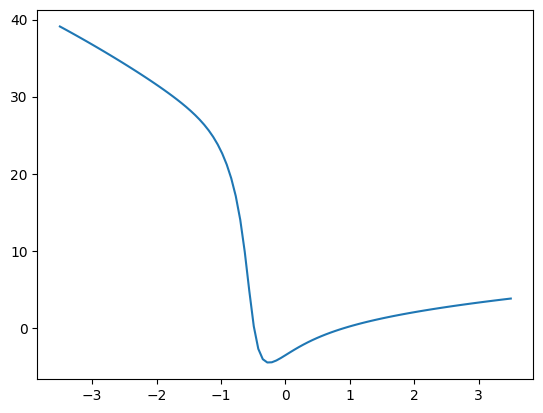

In [50]:
plt.plot(J_parallel_sweep/J, chiral_order_parameters)

In [51]:
keys = ('simulation', 'no_dephasing')


data_filename = 'chiral_order_parameter_simulation_data.h5'


data_dictionary = {
    'J_parallel_sweep': J_parallel_sweep,
    'chiral_order_parameters': chiral_order_parameters,
    'J': J,
    'U': U,
}

update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)

# 2. With Dephasing

### 2.1 Import T2s from config file

In [32]:
config_filename = 'current_correlations_config.json'

with open(config_filename, "r") as f:
    config = json.load(f)

print("Loaded config keys:", list(config.keys()))


coupling_points = [
    "coupling_point_1",
    "coupling_point_2",
    "coupling_point_3",
    "coupling_point_4",
    "coupling_point_5",
    "coupling_point_6",

]

all_T2s = np.zeros((len(coupling_points), num_qubits))


for coupling_point in coupling_points:

    coupling_point_index = int(coupling_point.split('_')[2]) - 1
    T2_dict = config[coupling_point]['T2s']

    print(coupling_point)
    print(T2_dict)

    for T2_qubit in T2_dict:
        qubit_index = int(T2_qubit.split('_')[-1]) - 1
        all_T2s[coupling_point_index, qubit_index] = T2_dict[T2_qubit]

print(all_T2s)

min_T2s = np.min(all_T2s, axis=0)
max_T2s = np.max(all_T2s, axis=0)
average_T2s = np.mean(all_T2s, axis=0)

print(min_T2s)
print(max_T2s)
print(average_T2s)

Loaded config keys: ['coupling_point_1', 'coupling_point_2', 'coupling_point_3', 'coupling_point_4', 'coupling_point_5', 'coupling_point_6', 'coupling_point_5_retake', 'coupling_point_6_retake']
coupling_point_1
{'T2_1': 1.044, 'T2_2': 0.959, 'T2_3': 0.526, 'T2_4': 1.001, 'T2_5': 0.652, 'T2_6': 0.587, 'T2_7': 1.479, 'T2_8': 0.835}
coupling_point_2
{'T2_1': 2.085, 'T2_2': 0.581, 'T2_3': 1.976, 'T2_4': 0.366, 'T2_5': 2.119, 'T2_6': 2.005, 'T2_7': 1.727, 'T2_8': 1.792}
coupling_point_3
{'T2_1': 1.467, 'T2_2': 0.535, 'T2_3': 1.543, 'T2_4': 0.422, 'T2_5': 2.396, 'T2_6': 2.036, 'T2_7': 1.371, 'T2_8': 1.621}
coupling_point_4
{'T2_1': 2.186, 'T2_2': 0.74, 'T2_3': 2.597, 'T2_4': 1.485, 'T2_5': 2.077, 'T2_6': 2.522, 'T2_7': 2.33, 'T2_8': 1.934}
coupling_point_5
{'T2_1': 1.889, 'T2_2': 1.049, 'T2_3': 3.371, 'T2_4': 0.555, 'T2_5': 3.472, 'T2_6': 1.0, 'T2_7': 1.604, 'T2_8': 1.599}
coupling_point_6
{'T2_1': 1.467, 'T2_2': 0.535, 'T2_3': 1.543, 'T2_4': 0.422, 'T2_5': 2.396, 'T2_6': 2.036, 'T2_7': 1.3

### 2.2 Sweep $J_{||}/J$

In [33]:
### initialize parameters

dephasing = 1.0
dephasing = 'real_min'


J = 5.5 * 2 * np.pi # 2pi MHz
U = -180 * 2 * np.pi # 2pi MHz

T1 = None
T2 = None

psi0 = -1
times = np.linspace(0, 0.15, 11)


ratios = np.linspace(-3.5, 3.5, 11)
ratios = np.linspace(-3.5, 3.5, 31)
ratios = np.array([-3.5,-3.2,3.2,3.5])
# ratios = np.array([1])

J_parallel_sweep = J * ratios

In [34]:
num_levels = 5
num_qubits = 8
num_particles = 4

basis = list(product(range(num_levels), repeat=num_qubits))
basis_4Q = [state for state in basis if sum(state) == num_particles]




correlation_pairs = []
for i in range(1, 8):
    for j in range(i + 2, 8):
        correlation_pairs.append(((i, i+1), (j,j+1)))



In [35]:
ramp_time_ns = 290 # ns

Q8_couplings_3m = {}

for i in range(num_qubits - 1):
    Q8_couplings_3m[(i+1,i+2)] = J/1e3/2/np.pi


U_GHz_list = [-U/1e3/2/np.pi] * num_qubits


init_ff = np.array([0, -0.1, -0.1, 0, 0, -0.1, -0.1, 0]) * 1.5
expt_ff = [0,0,0,0,0,0,0,0]


if isinstance(dephasing, str):
    if dephasing == 'real_min':
        T2_list = np.array(min_T2s)*1e3 # ns
    if dephasing == 'real_max':
        T2_list = np.array(max_T2s)*1e3 # ns

else:
    T2_list = [dephasing*1e3]*num_qubits # ns

T2_list = np.array(T2_list, dtype=np.float64)

print(f'T2 list for dephasing {dephasing}: {T2_list} ')


T2 list for dephasing real_min: [1044.  535.  526.  366.  652.  587. 1371.  835.] 


In [36]:


# ramp_shape = simple_ramp
# tlist = np.linspace(0, ramp_time_ns, 5)




# Q8_3m = M_qubit_sys_reduced(w=[0]*num_qubits, U=U_GHz_list,
#             couplings=Q8_couplings_3m,
#                         time_deps = {1: ramp_shape(init_ff[0],expt_ff[0], ramp_time_ns),
#                                     2: ramp_shape(init_ff[1],expt_ff[1], ramp_time_ns),
#                                     3: ramp_shape(init_ff[2],expt_ff[2], ramp_time_ns),
#                                     4: ramp_shape(init_ff[3],expt_ff[3], ramp_time_ns),
#                                     5: ramp_shape(init_ff[4],expt_ff[4], ramp_time_ns),
#                                     6: ramp_shape(init_ff[5],expt_ff[5], ramp_time_ns),
#                                     7: ramp_shape(init_ff[6],expt_ff[6], ramp_time_ns),
#                                     8: ramp_shape(init_ff[7],expt_ff[7], ramp_time_ns)},
#                         T2s=T2_list,
#                 RWA=True, N=5, reduce_Hamil_to_n=4)

# prep_state = Q8_3m.reduce_ket(Q8_3m.fock([1,0,0,1,1,0,0,1]))

# res = Q8_3m.mesolve(prep_state, tlist, options={'store_states':True}, plot=False)

# final_state = res.states[-1]

# true_eigenstate = Q8_3m.eigstates(4)[-1]
# overlap = np.abs(final_state.overlap(true_eigenstate))

# psi0_state = final_state

In [37]:



chiral_order_parameters = []

for i in range(len(J_parallel_sweep)):

    J_parallel = J_parallel_sweep[i]

    for i in range(num_qubits - 2):
        Q8_couplings_3m[(i+1,i+3)] = J_parallel/1e3/2/np.pi


    ramp_shape = simple_ramp
    tlist = np.linspace(0, ramp_time_ns, 5)




    Q8_3m = M_qubit_sys_reduced(w=[0]*num_qubits, U=U_GHz_list,
                couplings=Q8_couplings_3m,
                            time_deps = {1: ramp_shape(init_ff[0],expt_ff[0], ramp_time_ns),
                                        2: ramp_shape(init_ff[1],expt_ff[1], ramp_time_ns),
                                        3: ramp_shape(init_ff[2],expt_ff[2], ramp_time_ns),
                                        4: ramp_shape(init_ff[3],expt_ff[3], ramp_time_ns),
                                        5: ramp_shape(init_ff[4],expt_ff[4], ramp_time_ns),
                                        6: ramp_shape(init_ff[5],expt_ff[5], ramp_time_ns),
                                        7: ramp_shape(init_ff[6],expt_ff[6], ramp_time_ns),
                                        8: ramp_shape(init_ff[7],expt_ff[7], ramp_time_ns)},
                            T2s=T2_list,
                    RWA=True, N=5, reduce_Hamil_to_n=4)

    prep_state = Q8_3m.reduce_ket(Q8_3m.fock([1,0,0,1,1,0,0,1]))

    res = Q8_3m.mesolve(prep_state, tlist, options={'store_states':True}, plot=False)

    final_state = res.states[-1]

    true_eigenstate = Q8_3m.eigstates(4)[-1]
    overlap = np.abs(final_state.overlap(true_eigenstate))

    psi0_state = final_state

    current_simulation = CurrentSimulation(num_levels, num_qubits, num_particles, J_parallel, J, 0, U)

    # create fock state out of psi0

    basis_4Q_fock = [FockBasisState(state) for state in basis_4Q]

    # basis_fock = [FockBasisState(state) for state in basis]

    psi0_fock_basis = []
    psi0_fock_state = []

    trace_sum = 0

    for i in range(len(basis_4Q)):
        for j in range(len(basis_4Q)):
            coeff = psi0_state.full()[i,j]
            if abs(coeff) > 1e-10:
                psi0_fock_basis.append(FockBasisOuter(basis_4Q[i], basis_4Q[j]))
                psi0_fock_state.append(coeff)

        trace_sum += psi0_state.full()[i,i]

    psi0_fock = DensityMatrix(np.array(psi0_fock_state), psi0_fock_basis)

    current_simulation.psi0 = psi0_fock
    current_correlations_from_operator = current_simulation.get_current_correlations(only_rungs=True)

    # remove pairs that share a vertex, and redefine signs (1,2),(4,5) is positive in pi flux

    current_correlations_from_operator_normalized = {}

    for correlation_pair in correlation_pairs:
        pair_1, pair_2 = correlation_pair

        multiplier = 1
        if abs(min(pair_1) - min(pair_2)) % 2 == 1:
            multiplier = -1

        current_correlations_from_operator_normalized[correlation_pair] = current_correlations_from_operator[correlation_pair]
        current_correlations_from_operator_normalized[correlation_pair] *= multiplier



    current_correlation_by_distance_operator = {}


    for correlation_pair in correlation_pairs:

        current_correlation_value = current_correlations_from_operator_normalized[correlation_pair]

        distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))

        if not distance in current_correlation_by_distance_operator:
            current_correlation_by_distance_operator[distance] = []
        
        current_correlation_by_distance_operator[distance].append(current_correlation_value)


    distances = []
    current_correlation_averages_operator = []

    for distance in current_correlation_by_distance_operator:
        distances.append(distance)
        current_correlation_averages_operator.append(np.mean(current_correlation_by_distance_operator[distance]))


    current_correlation_total_operator = sum(current_correlation_averages_operator)
    print(f'current correlation total operator: {current_correlation_total_operator}')

    # we need to create the full data dictionary because it doesn't update nested items


    data_dictionary = {}

    for correlation_pair in correlation_pairs:

        data_dictionary[correlation_pair] = {}


        data_dictionary[correlation_pair]['current_correlation_value'] = current_correlations_from_operator_normalized[correlation_pair]

    data_dictionary['distances'] = distances

    data_dictionary['current_correlation_averages'] = current_correlation_averages_operator
    data_dictionary['distance_to_current_correlation_value'] = current_correlation_by_distance_operator
    data_dictionary['current_correlation_total'] = current_correlation_total_operator


    chiral_order_parameters.append(current_correlation_total_operator)

    

Reduced 390625^2-dimensional subspace to a 330^2-dimensional one.
[None, None, None, None, None, None, None, None, None]
[  nan 1044.  535.  526.  366.  652.  587. 1371.  835.]
0.0009578544061302681
0.001869158878504673
0.0019011406844106464
0.00273224043715847
0.0015337423312883436
0.0017035775127768314
0.0007293946024799417
0.0011976047904191617
5 time steps for 8 qubits and N=5 took 94.33417797088623 seconds to simulate.
Hamiltonian of shape (330, 330) took 0.09050822257995605 seconds to diagonalize.
current correlation total operator: 20.474919895937546
Reduced 390625^2-dimensional subspace to a 330^2-dimensional one.
[None, None, None, None, None, None, None, None, None]
[  nan 1044.  535.  526.  366.  652.  587. 1371.  835.]
0.0009578544061302681
0.001869158878504673
0.0019011406844106464
0.00273224043715847
0.0015337423312883436
0.0017035775127768314
0.0007293946024799417
0.0011976047904191617
5 time steps for 8 qubits and N=5 took 107.3337607383728 seconds to simulate.
Hamilton

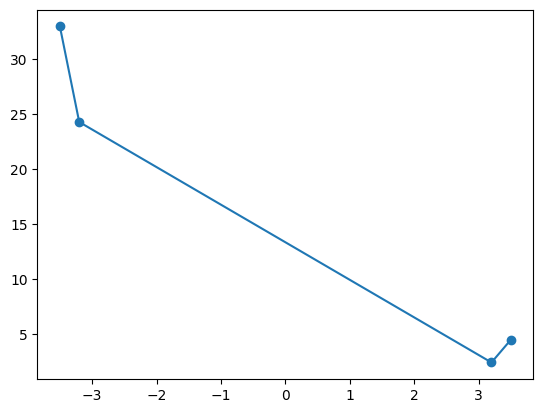

In [ ]:
plt.plot(J_parallel_sweep/J, chiral_order_parameters, marker='o')

In [38]:


keys = ('simulation', dephasing)

keys = ('simulation', 'real_min_2')
# raise Exception('stop')


data_filename = 'chiral_order_parameter_simulation_data.h5'


data_dictionary = {
    'J_parallel_sweep': J_parallel_sweep,
    'chiral_order_parameters': chiral_order_parameters,
    'J': J,
    'U': U,
}

update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)

# 3. Plots

In [45]:
data_filename = 'chiral_order_parameter_simulation_data.h5'

loaded_data = load_nested_dict_from_hdf5(data_filename)
print_tree(loaded_data)

print(loaded_data['simulation']['real_min']['chiral_order_parameters'])

simulation
- 1.0
- - J_parallel_sweep
- - chiral_order_parameters
- - J
- - U
- no_dephasing
- - J_parallel_sweep
- - chiral_order_parameters
- - J
- - U
- real_max
- - J_parallel_sweep
- - chiral_order_parameters
- - J
- - U
- real_max_2
- - J_parallel_sweep
- - chiral_order_parameters
- - J
- - U
- real_min
- - J_parallel_sweep
- - chiral_order_parameters
- - J
- - U
- real_min_2
- - J_parallel_sweep
- - chiral_order_parameters
- - J
- - U
[19.04476568 14.88074584 16.12271324 16.42022664 16.5004579  16.41557084
 14.01954696 14.0580518  14.73339391 16.27111964 12.32381727  5.98171415
  0.9374092  -9.26566564 -4.06444462 -0.49939407 -1.26048342 -1.16618167
 -0.91481657  0.66828116 -0.02739747  0.72124002  0.72957468  1.02424323
  0.8947807   0.84921468  1.5590014   1.00236739  1.35711446  1.90782232
  1.81768675]


In [46]:
### let's import the current correlations data
correlations_data_filename = 'current_correlations_data.h5'

correlations_data = load_nested_dict_from_hdf5(correlations_data_filename)


print_tree(correlations_data['simulation']['highest']['no_dephasing'], max_level=1)

coupling_point_1
coupling_point_2
coupling_point_3
coupling_point_4
coupling_point_5
coupling_point_6


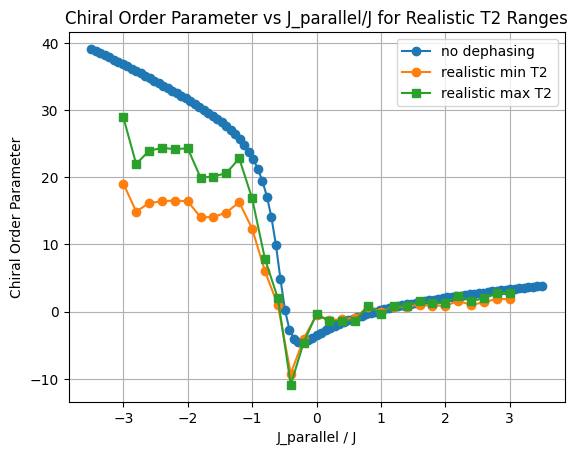

In [47]:
no_dephasing_chiral_order_parameters = loaded_data['simulation']['no_dephasing']['chiral_order_parameters']
no_dephasing_J_parallel_sweep = loaded_data['simulation']['no_dephasing']['J_parallel_sweep']
no_dephasing_J = loaded_data['simulation']['no_dephasing']['J']


real_min_chiral_order_parameters = loaded_data['simulation']['real_min']['chiral_order_parameters']
real_min_J_parallel_sweep = loaded_data['simulation']['real_min']['J_parallel_sweep']
real_min_J = loaded_data['simulation']['real_min']['J']

real_max_chiral_order_parameters = loaded_data['simulation']['real_max']['chiral_order_parameters']
real_max_J_parallel_sweep = loaded_data['simulation']['real_max']['J_parallel_sweep']
real_max_J = loaded_data['simulation']['real_max']['J']


plt.plot(no_dephasing_J_parallel_sweep/no_dephasing_J, no_dephasing_chiral_order_parameters, marker='o', label='no dephasing')
plt.plot(real_min_J_parallel_sweep/real_min_J, real_min_chiral_order_parameters, marker='o', label='realistic min T2')
plt.plot(real_max_J_parallel_sweep/real_max_J, real_max_chiral_order_parameters, marker='s', label='realistic max T2')

plt.xlabel('J_parallel / J')
plt.ylabel('Chiral Order Parameter')
plt.title('Chiral Order Parameter vs J_parallel/J for Realistic T2 Ranges')
plt.legend()
plt.grid()
plt.show()


In [48]:
print_tree(correlations_data['simulation']['highest']['no_dephasing'], max_level=1)

coupling_point_1
coupling_point_2
coupling_point_3
coupling_point_4
coupling_point_5
coupling_point_6


In [49]:
print(correlations_data['data']['coupling_point_1']['highest_postselection']['current_correlation_total'] )
print(correlations_data['data']['coupling_point_2']['highest_postselection']['current_correlation_total'] )
print(correlations_data['data']['coupling_point_3']['highest_postselection']['current_correlation_total'] )
print(correlations_data['data']['coupling_point_4']['highest_postselection']['current_correlation_total'] )
print(correlations_data['data']['coupling_point_5']['highest_postselection']['current_correlation_total'] )
print(correlations_data['data']['coupling_point_6']['highest_postselection']['current_correlation_total'] )


9.775828253245317
10.580432766758474
3.313785227276006
0.011166922696428938
0.050390634622124036
0.22408837726148834


In [50]:
coupling_points = [
    'coupling_point_1',
    'coupling_point_2',
    'coupling_point_3',
    'coupling_point_4',
    'coupling_point_5',
    'coupling_point_6',

]

[-5.74857143 -6.04857143 -4.88857143 -6.41571429 -6.61       -4.93428571]
-5.774285714285714
[-1.21711398 -2.01948512 -3.56204948  0.97572924  1.96369138  3.52904845]
[9.775828253245317, 16.561978979573674, 6.545125826728219, 0.2930667019801857, -1.7946490446012335, -1.428127241332853]


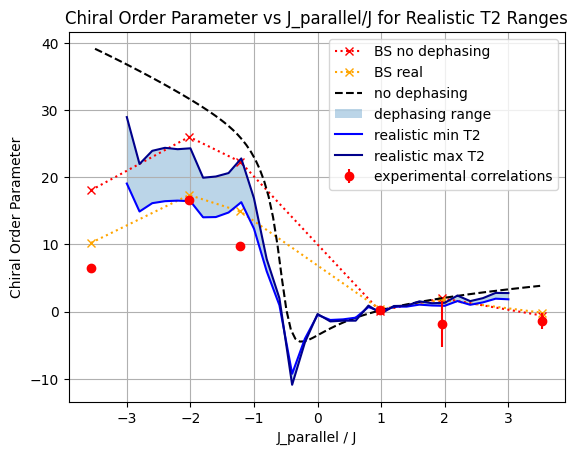

In [ ]:
total_correlations = [correlations_data['data'][coupling_point]['highest_postselection']['current_correlation_total'] for coupling_point in coupling_points]
total_correlations = [correlations_data['data'][coupling_point]['highest']['current_correlation_total'] for coupling_point in coupling_points]





chiral_order_parameters_sim_BS_no_dephasing = np.array([correlations_data['simulation']['highest']['no_dephasing'][coupling_point]['current_correlation_BS_total'] for coupling_point in coupling_points])
chiral_order_parameters_sim_BS_real = np.array([correlations_data['simulation']['highest']['real'][coupling_point]['current_correlation_BS_total'] for coupling_point in coupling_points])

average_rung_couplings = np.array([config[coupling_point]['coupling']['average_rung_coupling'] for coupling_point in coupling_points])
average_leg_couplings = np.array([config[coupling_point]['coupling']['average_leg_coupling'] for coupling_point in coupling_points])

data_ratios = -average_leg_couplings/average_rung_couplings

print(average_rung_couplings)
print(np.mean(average_rung_couplings))
print(data_ratios)


sorted_indices = np.argsort(data_ratios)


plt.plot(data_ratios[sorted_indices], chiral_order_parameters_sim_BS_no_dephasing[sorted_indices], color='red', linestyle=':', marker='x', label='BS no dephasing')
plt.plot(data_ratios[sorted_indices], chiral_order_parameters_sim_BS_real[sorted_indices], color='orange', linestyle=':', marker='x', label='BS real')


plt.plot(no_dephasing_J_parallel_sweep/no_dephasing_J, no_dephasing_chiral_order_parameters, color='black', linestyle='--', label='no dephasing')

# fill between real min and real max
plt.fill_between(real_min_J_parallel_sweep/real_min_J, real_min_chiral_order_parameters, real_max_chiral_order_parameters, alpha=0.3, label='dephasing range')
plt.plot(real_min_J_parallel_sweep/real_min_J, real_min_chiral_order_parameters, color='blue', label='realistic min T2')
plt.plot(real_max_J_parallel_sweep/real_max_J, real_max_chiral_order_parameters, color='darkblue', label='realistic max T2')



print(total_correlations)
plt.errorbar(data_ratios, total_correlations, yerr=total_correlations_error, color='red', linestyle='', marker='o', label='experimental correlations')

plt.xlabel('J_parallel / J')
plt.ylabel('Chiral Order Parameter')
plt.title('Chiral Order Parameter vs J_parallel/J for Realistic T2 Ranges')
plt.legend()
plt.grid()
plt.show()

In [63]:
coupling_points

['coupling_point_1',
 'coupling_point_2',
 'coupling_point_3',
 'coupling_point_4',
 'coupling_point_5',
 'coupling_point_6']

dict_keys(['((1, 2), (3, 4))', '((1, 2), (4, 5))', '((1, 2), (5, 6))', '((1, 2), (6, 7))', '((1, 2), (7, 8))', '((2, 3), (4, 5))', '((2, 3), (5, 6))', '((2, 3), (6, 7))', '((2, 3), (7, 8))', '((3, 4), (5, 6))', '((3, 4), (6, 7))', '((3, 4), (7, 8))', '((4, 5), (6, 7))', '((4, 5), (7, 8))', '((5, 6), (7, 8))', 'current_correlation_average_errors', 'current_correlation_average_readout_std_error', 'current_correlation_averages', 'distance_to_current_correlation_error', 'distance_to_current_correlation_value', 'distance_to_readout_std_error_value', 'distances', 'current_correlation_total', 'current_correlation_total_error', 'current_correlation_total_readout_std_error'])
[ 9.77582825 10.58043277  3.31378523  0.01116692  0.05039063  0.22408838]


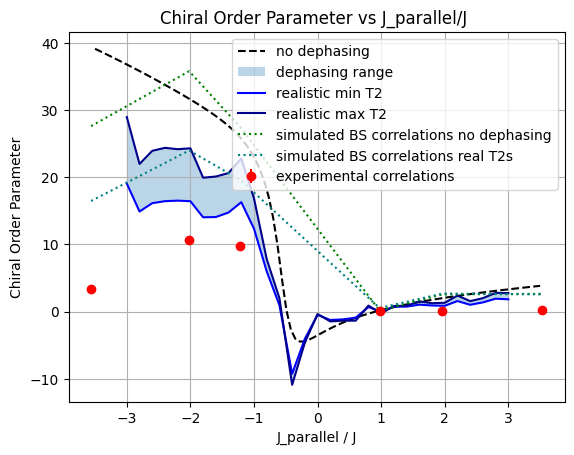

In [68]:
### load in individual coupling point BS simulations as well
# these are more expensive so can't sweep J/J_||

total_correlations_sim_BS_no_dephasing = np.array([correlations_data['simulation']['highest']['no_dephasing'][coupling_point]['current_correlation_total'] for coupling_point in coupling_points])
total_correlations_sim_BS_real = np.array([correlations_data['simulation']['highest']['real'][coupling_point]['current_correlation_total'] for coupling_point in coupling_points])



### let's import the current correlations data
correlations_data_filename = 'current_correlations_data.h5'

correlations_data = load_nested_dict_from_hdf5(correlations_data_filename)


total_correlations = np.array([correlations_data['data'][coupling_point]['highest']['current_correlation_total'] for coupling_point in coupling_points])
total_correlations = np.array([correlations_data['data'][coupling_point]['highest_postselection']['current_correlation_total'] for coupling_point in coupling_points])

total_correlations_error = np.array([correlations_data['data'][coupling_point]['highest_postselection']['current_correlation_total_readout_std_error'] for coupling_point in coupling_points])

print(correlations_data['data']['coupling_point_1']['highest_postselection'].keys())

plt.plot(no_dephasing_J_parallel_sweep/no_dephasing_J, no_dephasing_chiral_order_parameters, color='black', linestyle='--', label='no dephasing')

# fill between real min and real max
plt.fill_between(real_min_J_parallel_sweep/real_min_J, real_min_chiral_order_parameters, real_max_chiral_order_parameters, alpha=0.3, label='dephasing range')
plt.plot(real_min_J_parallel_sweep/real_min_J, real_min_chiral_order_parameters, color='blue', label='realistic min T2')
plt.plot(real_max_J_parallel_sweep/real_max_J, real_max_chiral_order_parameters, color='darkblue', label='realistic max T2')


plt.plot(data_ratios[sorted_indices], total_correlations_sim_BS_no_dephasing[sorted_indices], color='green', linestyle=':', label='simulated BS correlations no dephasing' )
plt.plot(data_ratios[sorted_indices], total_correlations_sim_BS_real[sorted_indices], color='teal', linestyle=':',  label='simulated BS correlations real T2s' )

print(total_correlations)
plt.errorbar(data_ratios, total_correlations, yerr=total_correlations_error, color='red', linestyle='', marker='o', label='experimental correlations')

plt.xlabel('J_parallel / J')
plt.ylabel('Chiral Order Parameter')
plt.title('Chiral Order Parameter vs J_parallel/J ')
plt.legend()
plt.grid()
plt.show()

In [74]:
sim_copmarison_all_points_filepath = 'plots/simulation_comparison_all_points.csv'

with open(sim_copmarison_all_points_filepath, 'w') as f:
    writer = csv.writer(f)

    writer.writerow(data_ratios[sorted_indices])
    writer.writerow(total_correlations[sorted_indices])
    writer.writerow(total_correlations_error[sorted_indices])
    writer.writerow(total_correlations_sim_BS_no_dephasing[sorted_indices])
    writer.writerow(total_correlations_sim_BS_real[sorted_indices])
    writer.writerow(no_dephasing_J_parallel_sweep/no_dephasing_J)
    writer.writerow(no_dephasing_chiral_order_parameters/((no_dephasing_J/(2*np.pi))**2))

    
    # order is
    # data ratios
    # data correlations
    # BS sim no dephasing
    # BS sim real T2

    # simulation ratios
    # simulation exact operator

    